# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

Paper presents the business need as improving campaign efficiency: make fewer contacts while retaining as many successful subscriptions as possible. This notebook translates that goal into a binary classification and ranking problem.

Total 17 campaigns were conducted between May 2008 and November 2010, corresponding to a total of 79354 contacts.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [37]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    make_scorer,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
    cross_val_predict
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier

import time
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
sns.set_theme(style="darkgrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
from IPython.display import display as show_table
from sklearn import set_config
set_config(working_memory=64)


The dataset is not included in this GitHub repository because it exceeds GitHub's file-size limit. Please download it from the course portal or the UCI machine learning link before running the notebook.

In [ ]:
df_org= pd.read_csv(r'data/bank-additional-full.csv', sep = ';')
df_org.shape

(41188, 21)

Original data has 41188 rows and 21 columns.

In [39]:
df_org.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



understanding the data types of each column is important for several reasons. It helps us to identify any potential issues with the data, 
such as missing values or incorrect data types, and allows us to choose appropriate methods for data analysis and modeling. Additionally,
understanding the data types can help us to optimize our code and improve performance when working with large datasets.

In [40]:
df_org.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

No missing value found. Data looks good.

In [41]:
Data_summary = pd.DataFrame(
    {
        "value": [
            df_org.shape[0],
            df_org.shape[1],
            int(df_org.isna().sum().sum()),
            int(df_org.duplicated().sum()),
        ]
    },
    index=["Rows", "Columns", "Missing values", "Duplicate rows"],
)

unknown_counts = (
    (df_org.select_dtypes(include=["object", "string"]) == "unknown")
    .sum()
    .loc[lambda values: values > 0]
    .sort_values(ascending=False)
    .to_frame("unknown_count")
)
unknown_counts["percent_of_rows"] = unknown_counts["unknown_count"] / len(df_org)

show_table(Data_summary)
unknown_counts_display = unknown_counts.copy()
unknown_counts_display["percent_of_rows"] = unknown_counts_display["percent_of_rows"].map(lambda value: f"{value:.1%}")
show_table(unknown_counts_display)



,value
Rows,41188
Columns,21
Missing values,0
Duplicate rows,12


,unknown_count,percent_of_rows
default,8597,20.9%
education,1731,4.2%
housing,990,2.4%
loan,990,2.4%
job,330,0.8%
marital,80,0.2%


In [42]:
#Dropping duplicate rows is a common data cleaning step that helps to ensure the accuracy and reliability of the analysis.

df = df_org.drop_duplicates().reset_index(drop=True).copy()

#renaming the target variable to "subscribed" and mapping the values to 0 and 1 is a common preprocessing step in binary classification problems.
df["subscribed"] = df["y"].map({"no": 0, "yes": 1})

print(f"Analysis dataset after cleaning: {df.shape[0]:,} rows")

Analysis dataset after cleaning: 41,176 rows


In [43]:
#seprating categorical and numerical columns for further analysis
categorical_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed']


In [44]:
#grouping the columns based on their characteristics. This can help to identify patterns and relationships between the features, and can also be useful for feature selection and engineering.

groups = np.repeat(
    ["Customer", "Current contact", "Campaign history",
     "Macroeconomic", "Target"],
    [7, 4, 4, 5, 1]
)

feature_dictionary = pd.DataFrame({
    "feature_group": groups,
    "feature": df_org.columns,
    "type": [
        "numeric" if pd.api.types.is_numeric_dtype(df_org[col])
        else "categorical"
        for col in df_org.columns
    ]
})

show_table(feature_dictionary)

,feature_group,feature,type
0,Customer,age,numeric
1,Customer,job,categorical
2,Customer,marital,categorical
3,Customer,education,categorical
4,Customer,default,categorical
5,Customer,housing,categorical
6,Customer,loan,categorical
7,Current contact,contact,categorical
8,Current contact,month,categorical
9,Current contact,day_of_week,categorical


In [45]:
#statistical summary 

df_org.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,"41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000"
mean,40.0241,258.2850,2.5676,962.4755,0.1730,0.0819,93.5757,-40.5026,3.6213,"5,167.0359"
std,10.4212,259.2792,2.7700,186.9109,0.4949,1.5710,0.5788,4.6282,1.7344,72.2515
min,17.0000,0.0000,1.0000,0.0000,0.0000,-3.4000,92.2010,-50.8000,0.6340,"4,963.6000"
25%,32.0000,102.0000,1.0000,999.0000,0.0000,-1.8000,93.0750,-42.7000,1.3440,"5,099.1000"
50%,38.0000,180.0000,2.0000,999.0000,0.0000,1.1000,93.7490,-41.8000,4.8570,"5,191.0000"
75%,47.0000,319.0000,3.0000,999.0000,0.0000,1.4000,93.9940,-36.4000,4.9610,"5,228.1000"
max,98.0000,"4,918.0000",56.0000,999.0000,7.0000,1.4000,94.7670,-26.9000,5.0450,"5,228.1000"


statistical summary of the dataset provides information about the distribution of the numerical features, such as the mean,
standard deviation, minimum, and maximum values. This can help to identify any potential outliers or skewness in the data, and can also 
be useful for feature scaling and normalization.
It shows that data has no missing values, but pdays, duration, and campaign all need careful handling due to skew/outliers/sentinel values

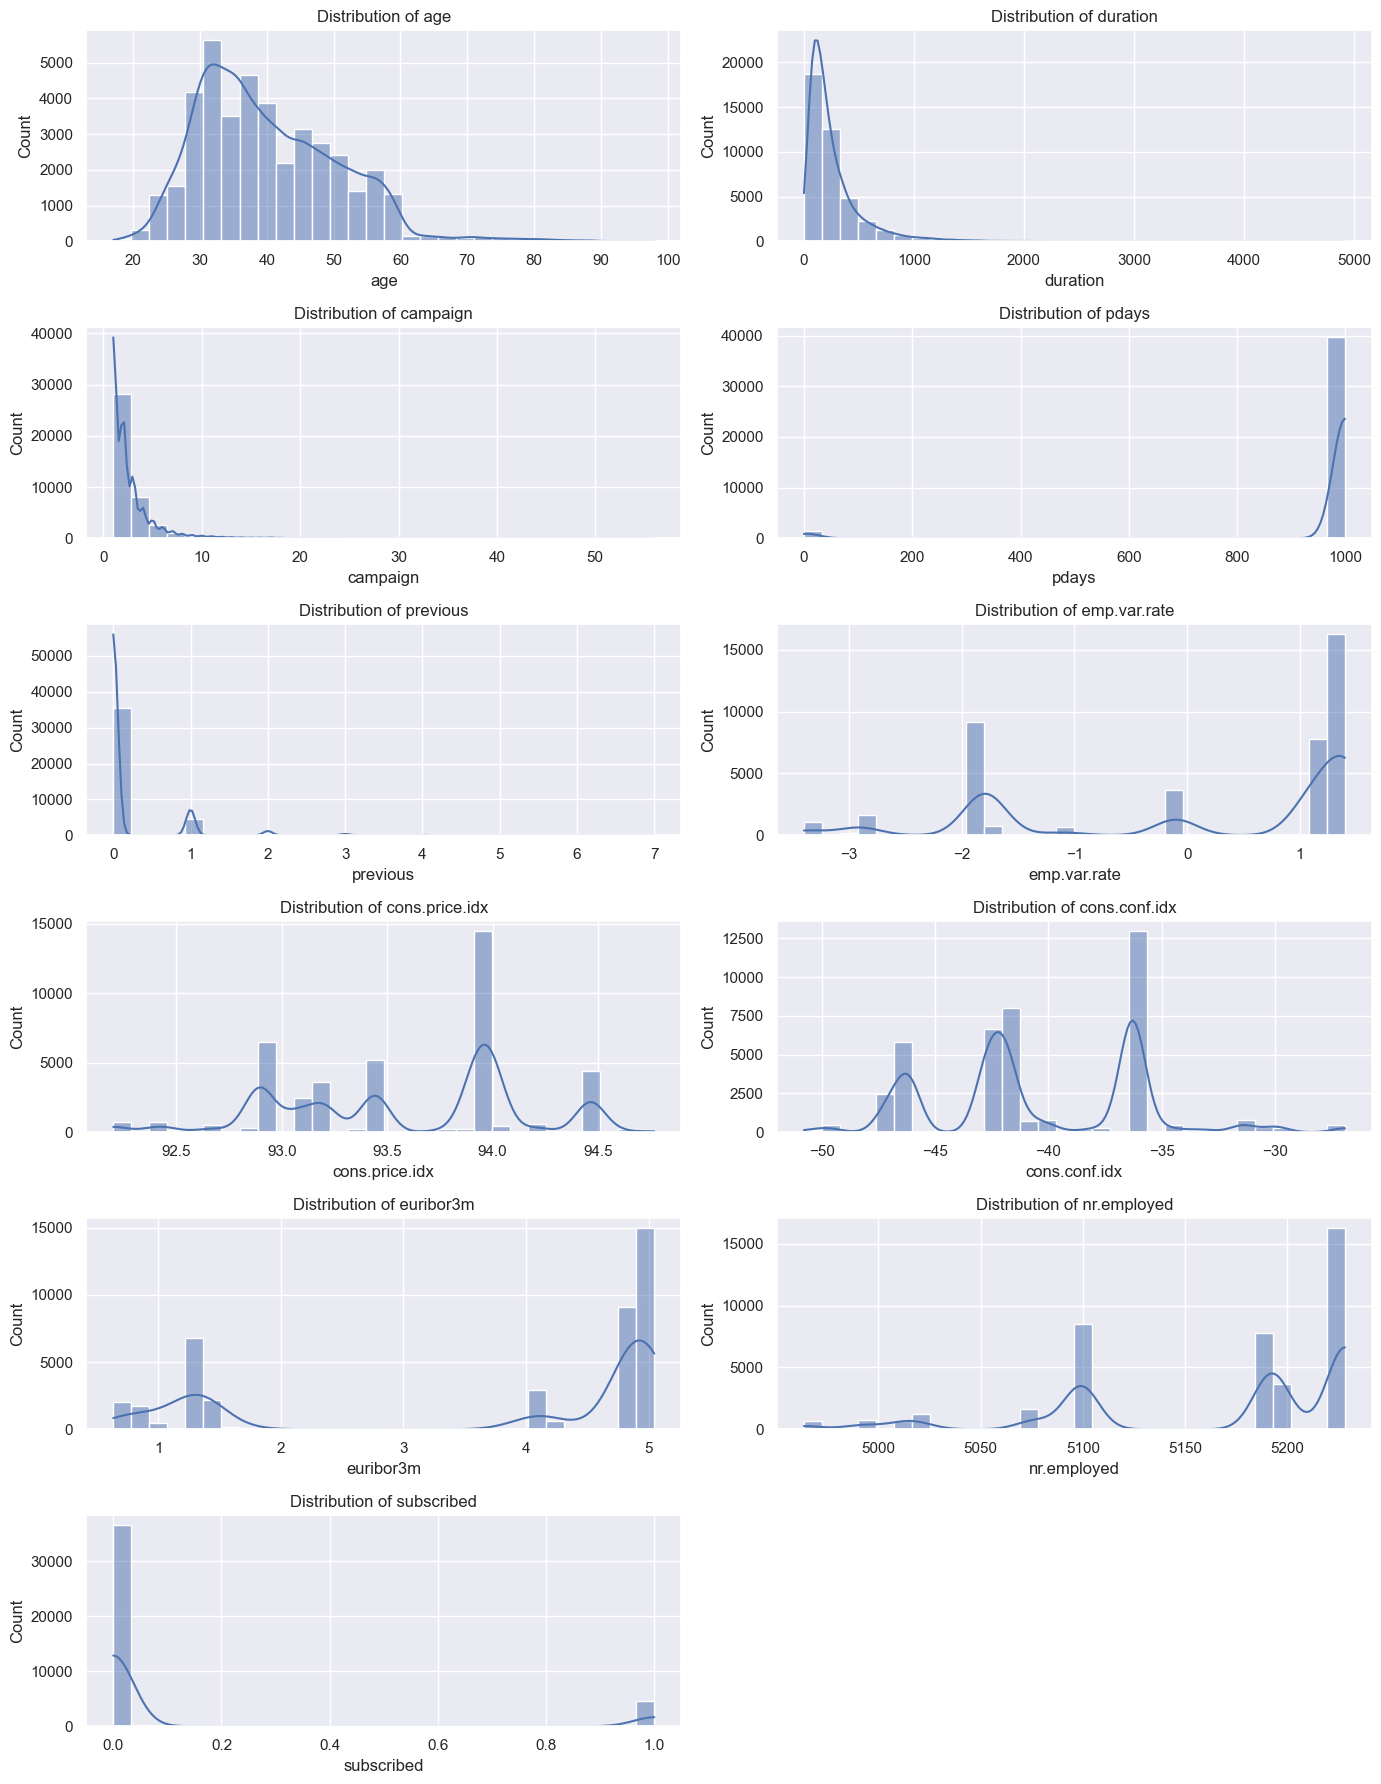

In [46]:
#Distribution of numerical features using histograms, which show the frequency of values in each bin. 

fig, axes = plt.subplots(6,2 ,figsize=(14,18))
axes = np.array(axes).flatten()

for i, column in enumerate(numerical_columns):
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {column}")

# Hide any unused subplot
for i in range(len(numerical_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

The dataset has 41,188 records, and the numerical columns do not appear to have any missing values. The average customer age is about 40 years, with ages ranging from 17 to 98. The age distribution appears to be slightly right-skewed.

Call duration is strongly right-skewed. The median call lasts 180 seconds, but the longest call is 4,918 seconds, showing that there are some unusually long calls. The `campaign` variable is also right-skewed. Most customers were contacted between one and three times, while the maximum was 56 contacts.

Most values in `pdays` are 999. This value means that the customer was not contacted during a previous campaign, so it should not be treated as the actual number of days. The median value of `previous` is zero, which also indicates that most customers had no previous campaign contact.

The economic variables have smaller ranges. The `euribor3m` variable shows noticeable variation, while `cons.price.idx` changes very little. Overall, some numerical variables are skewed and contain possible outliers, so they should be examined and handled carefully before building the models.


## EDA

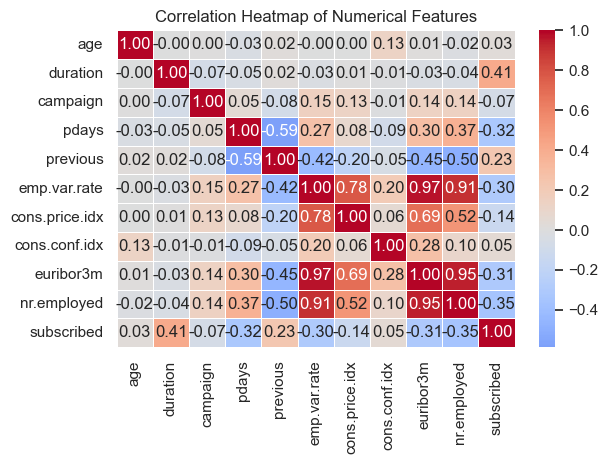

In [47]:
correlation_mat= df[numerical_columns].corr()
sns.heatmap(
    correlation_mat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

The heatmap shows that call duration has the strongest positive relationship with subscription, with a correlation of 0.41. However, duration should not be used in the prediction model because it is only known after the call is completed. The number of previous contacts has a positive correlation of 0.23 with subscription. Some economic features, such as the Euribor rate, employment variation rate, and number of employees, have negative relationships with subscription. These economic features are also strongly correlated with each other. Most of the other numerical features have weak relationships with subscription. The pdays variable should be interpreted carefully because a value of 999 means that the customer was not previously contacted.

,count,percent
y,,
no,36537,88.7300
yes,4639,11.2700


Subscription rate: 11.27%
95% confidence interval: 10.96% to 11.57%


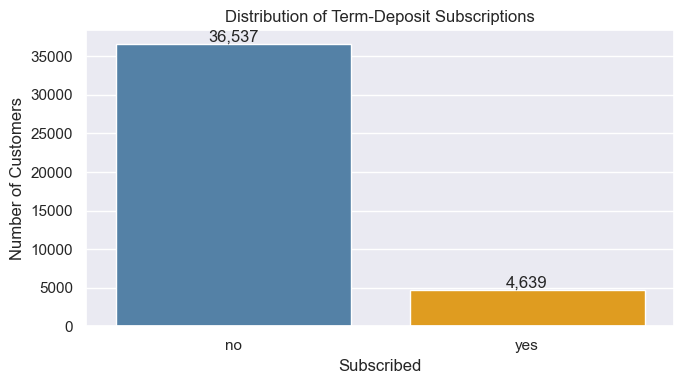

In [48]:
# Number and percentage of customers who subscribed
target_summary = pd.DataFrame({
    "count": df["y"].value_counts(),
    "percent": df["y"].value_counts(normalize=True) * 100
})

target_summary["percent"] = target_summary["percent"].round(2)
show_table(target_summary)

# Calculate the subscription rate and 95% confidence interval
n = len(df)
response_rate = df["subscribed"].mean()

standard_error = np.sqrt(
    response_rate * (1 - response_rate) / n
)

margin_of_error = 1.96 * standard_error
lower_limit = response_rate - margin_of_error
upper_limit = response_rate + margin_of_error

print(f"Subscription rate: {response_rate:.2%}")
print(f"95% confidence interval: {lower_limit:.2%} to {upper_limit:.2%}")

# Plot the target distribution
plt.figure(figsize=(7, 4))

ax = sns.countplot(
    data=df,
    x="y",
    hue="y",
    palette=["steelblue", "orange"],
    legend=False
)

plt.title("Distribution of Term-Deposit Subscriptions")
plt.xlabel("Subscribed")
plt.ylabel("Number of Customers")
# Add counts above the bars
for bar in ax.patches:
    count = int(bar.get_height())
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count,
        f"{count:,}",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()

The subscription rate was 11.27%. The approximate 95% confidence interval ranged from 10.96% to 11.57%, showing that subscriptions were uncommon in this dataset.

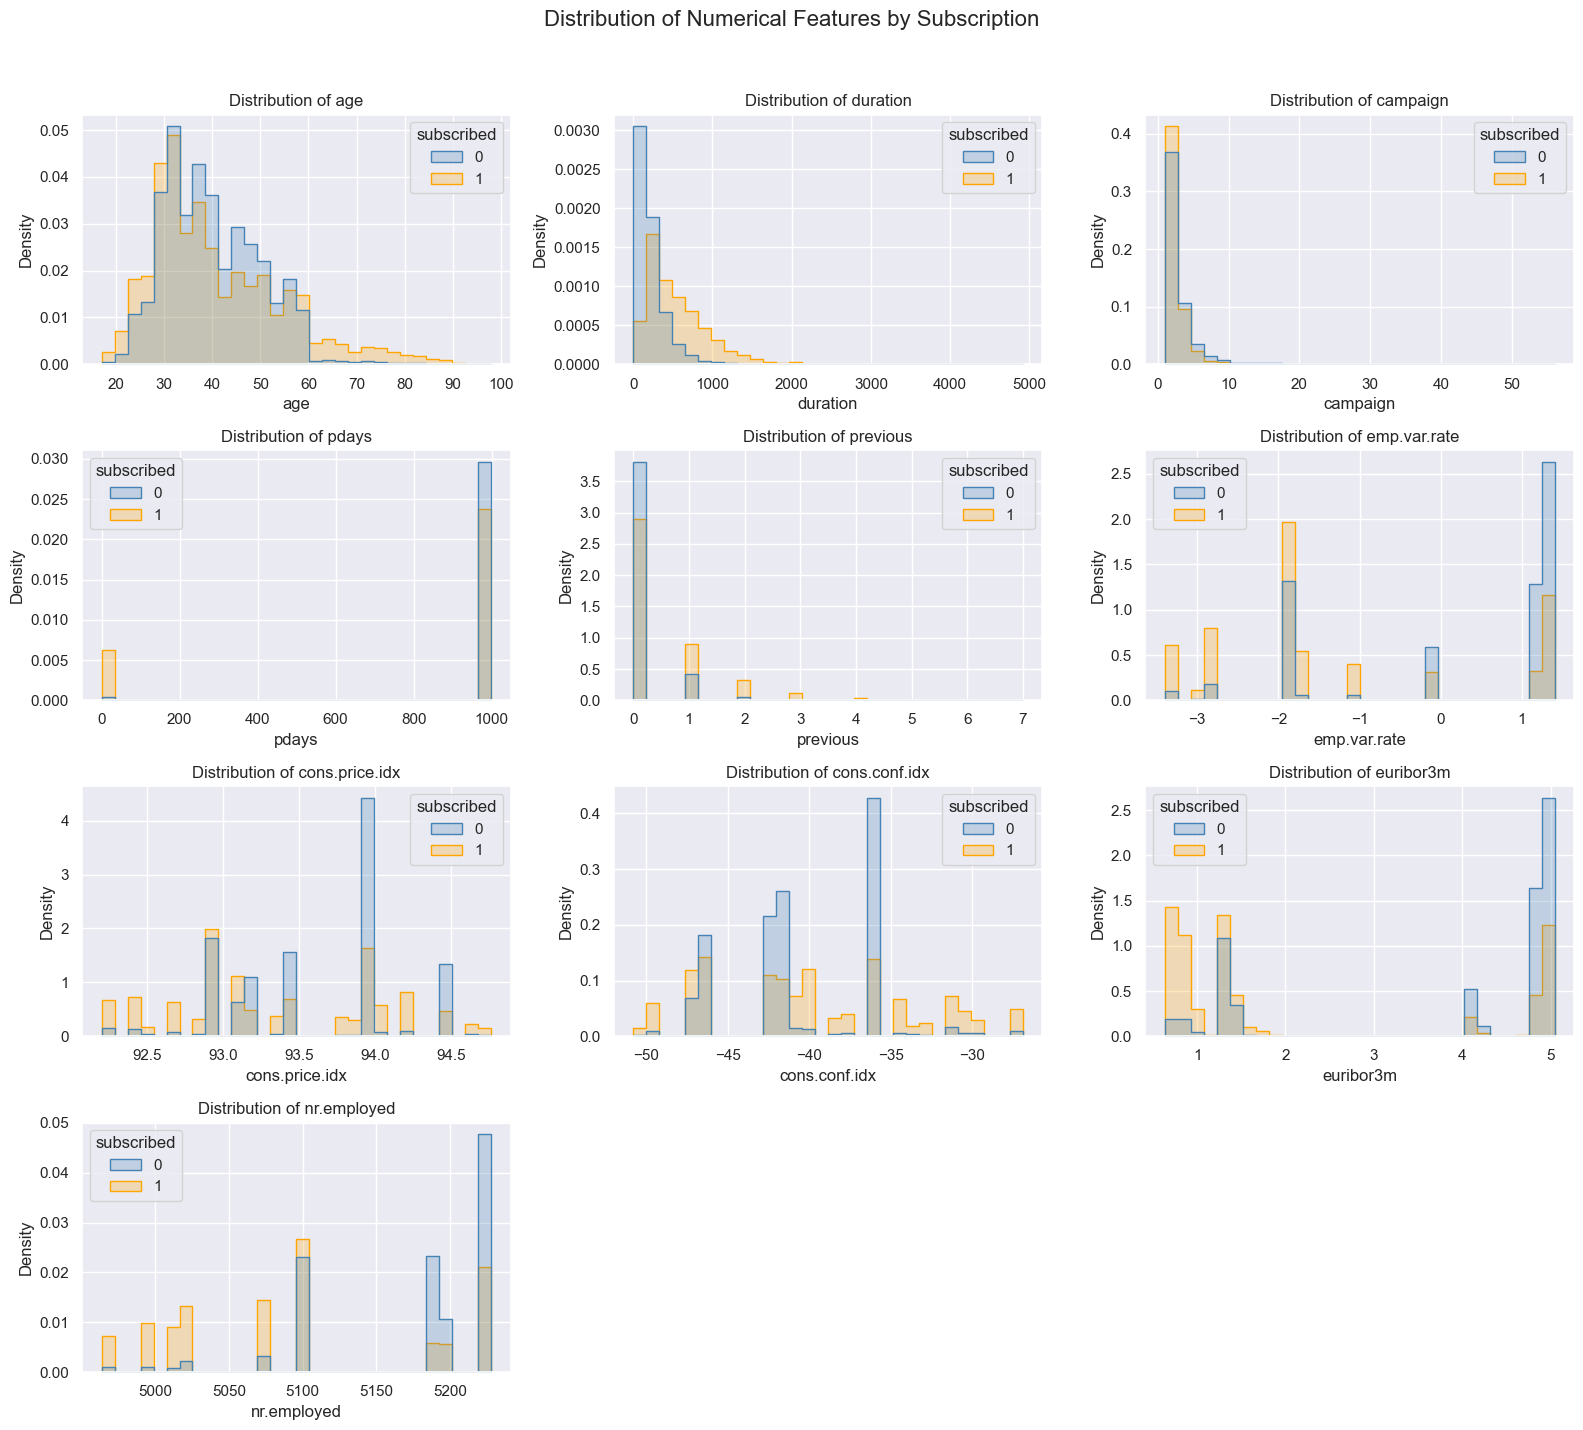

In [49]:
# Select numerical features
numerical_features = df[numerical_columns].columns.tolist()

# Remove the numerical target column
if "subscribed" in numerical_features:
    numerical_features.remove("subscribed")

# Identify the target column
target_column = df['subscribed']


number_of_columns = 3
number_of_rows = math.ceil(
    len(numerical_features) / number_of_columns
)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(16, 14)
)

axes = axes.flatten()

for index, feature in enumerate(numerical_features):
    sns.histplot(
        data=df,
        x=feature,
        hue=target_column,
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
        palette=["steelblue", "orange"],
        ax=axes[index]
    )

    axes[index].set_title(f"Distribution of {feature}")
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel("Density")

# Remove empty subplots
for index in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[index])

plt.suptitle(
    "Distribution of Numerical Features by Subscription",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

The histograms show some differences between customers who subscribed and those who did not.
 Customers who subscribed generally had longer call durations. However, duration should not be used in the prediction model because it is only known after the call is completed. 
 
 Age shows a large amount of overlap, although older customers appear slightly more common in the subscribed group. Most customers were contacted only a few times during the campaign, and additional contacts do not appear to increase subscriptions.

Most pdays values are 999, meaning that the customer was not previously contacted. Customers with previous campaign contacts appear more likely to subscribe. The economic features also show noticeable differences between the two groups. Subscriptions appear more common when the Euribor rate, employment variation rate, and number of employees are lower. Therefore, previous campaign information and economic conditions may be useful predictors.

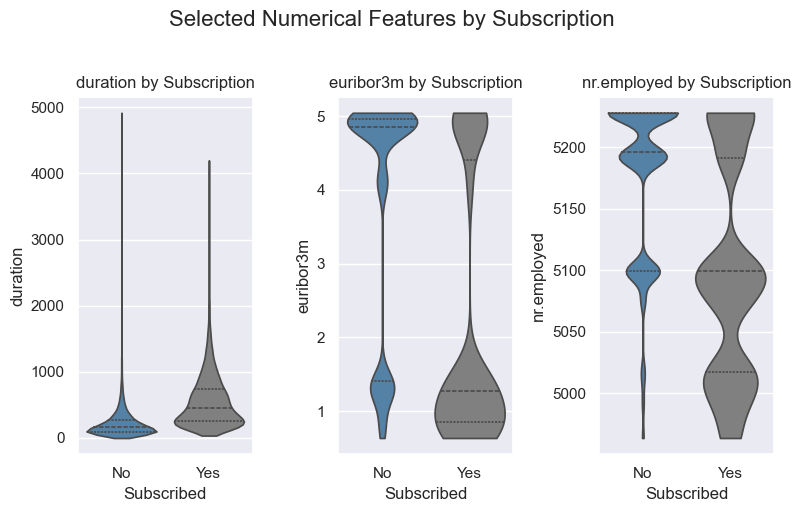

In [50]:

# Create a copy for plotting
df_violin = df.copy()
target_column = "subscribed" if "subscribed" in df.columns else "y"
df_violin["subscription_label"] = df_violin[target_column].replace({
    0: "No",
    1: "Yes",
    "no": "No",
    "yes": "Yes"
})

selected_features = [
    "duration",
    "euribor3m",
    "nr.employed"
]

fig, axes = plt.subplots(1, 3, figsize=(8, 5))
axes = axes.flatten()

for index, feature in enumerate(selected_features):
    sns.violinplot(
        data=df_violin,
        x="subscription_label",
        y=feature,
        hue="subscription_label",
        palette=["steelblue", "grey"],
        inner="quartile",
        cut=0,
        legend=False,
        ax=axes[index]
    )

    axes[index].set_title(f"{feature} by Subscription")
    axes[index].set_xlabel("Subscribed")
    axes[index].set_ylabel(feature)

plt.suptitle(
    "Selected Numerical Features by Subscription",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

The violin plots show noticeable differences between customers who subscribed and those who did not. Customers who subscribed generally had longer calls. However, call duration should not be included in the prediction model because it is only known after the call. Subscribers were also more commonly associated with lower Euribor rates and lower numbers of employees. These results suggest that economic conditions may be useful for predicting subscriptions. However, the economic variables are strongly related to each other, so their effects should be interpreted carefully.

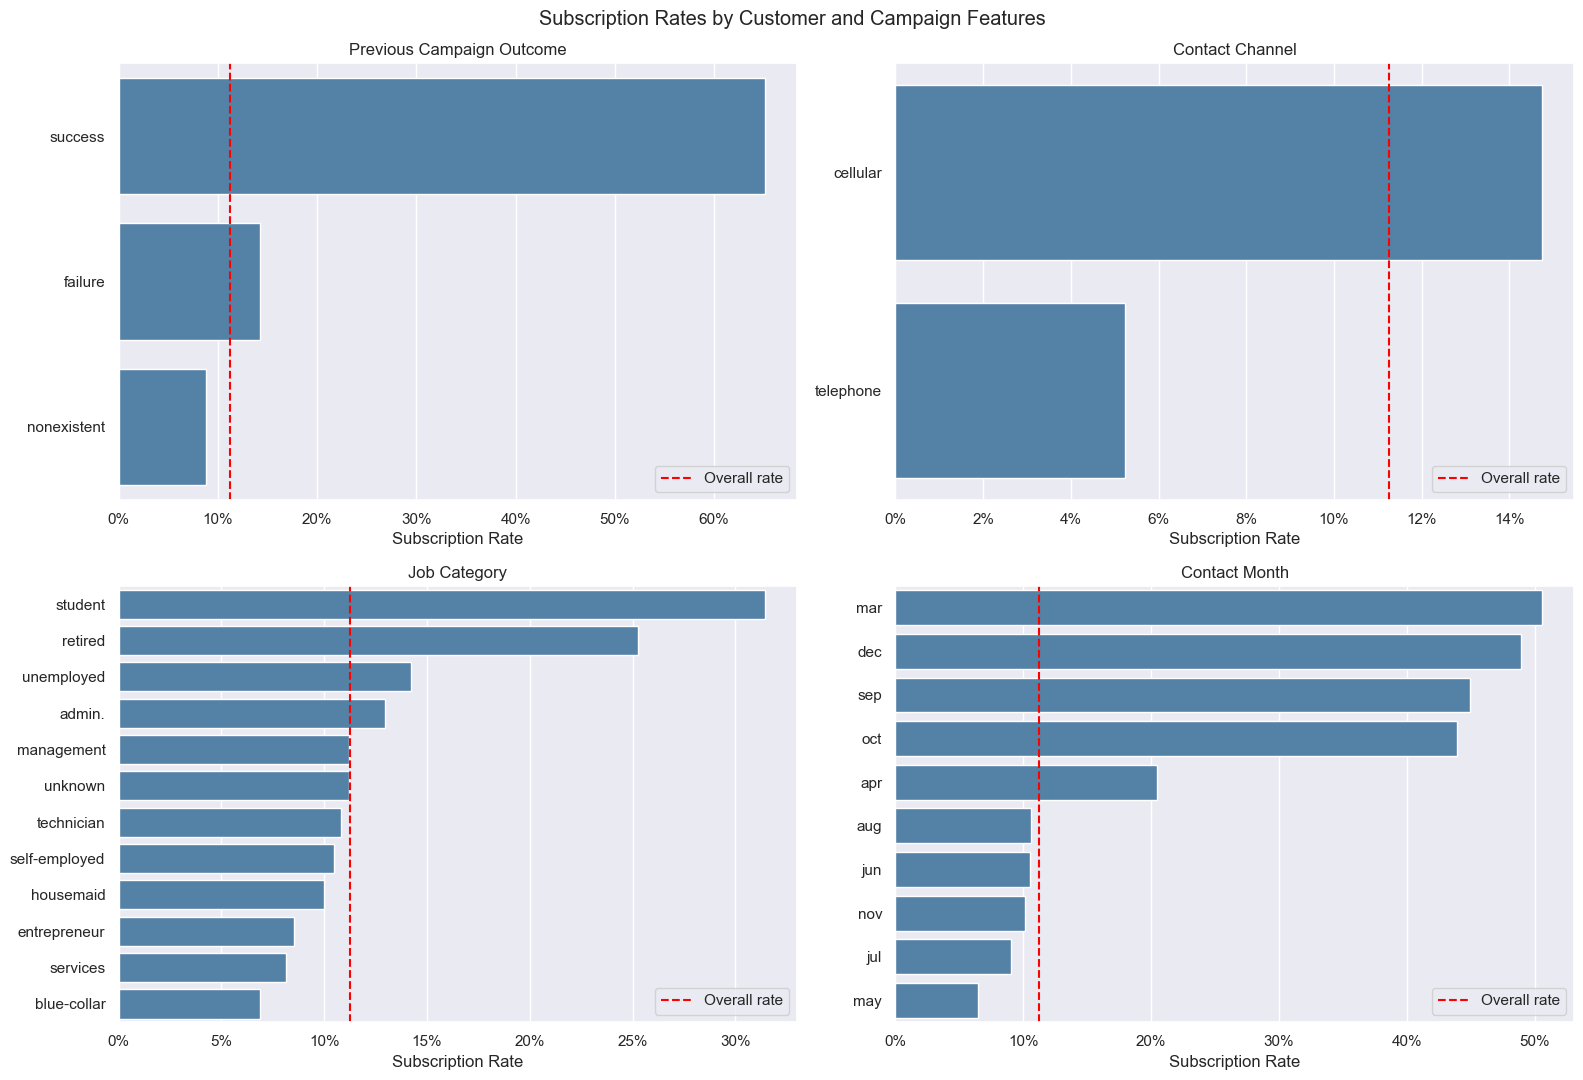

In [51]:
features = {
    "poutcome": "Previous Campaign Outcome",
    "contact": "Contact Channel",
    "job": "Job Category",
    "month": "Contact Month"
}

overall_rate = df["subscribed"].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for ax, (feature, title) in zip(axes.flatten(), features.items()):

    rates = (
        df.groupby(feature, observed=False)["subscribed"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    sns.barplot(
        data=rates,
        x="subscribed",
        y=feature,
        color="steelblue",
        ax=ax
    )

    ax.axvline(
        overall_rate,
        color="red",
        linestyle="--",
        label="Overall rate"
    )

    ax.set_title(title)
    ax.set_xlabel("Subscription Rate")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda value, _: f"{value:.0%}")
    )
    ax.legend()

plt.suptitle("Subscription Rates by Customer and Campaign Features")
plt.tight_layout()
plt.show()

Customers with a successful previous campaign outcome had the highest subscription rate. Cellular contacts performed better than telephone contacts. Students and retired customers showed higher response rates, while blue-collar and service workers had lower rates. March, December, September, and October had the highest subscription rates. These patterns show associations and do not necessarily mean that these features caused the subscriptions.

## EDA Inference

The EDA shows that only about 11% of customers subscribed, so the target is highly imbalanced.

 Call duration has the strongest relationship with subscription but will be excluded because it is unknown before the call.

 Previous campaign results, contact type, month, and economic conditions appear useful for prediction.
 
 Several economic variables are strongly correlated, and pdays contains the special value 999. Therefore, the data will require categorical encoding, numerical scaling, and a stratified train-test split before modeling.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

## Business Objective

The main business objective is to predict which customers are more likely to subscribe to a term deposit. The bank can use these predictions to identify customers who are more likely to respond positively, improve the efficiency of its telephone marketing campaigns, reduce unnecessary calls, and use its time and resources more effectively.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [52]:
#create df for feature engineering

df_feat = df.copy()

# Create a feature showing whether the customer was contacted previously
df_feat["previously_contacted"] = (df_feat["pdays"] != 999).astype(int)

# Replace 999 because it is not an actual number of days
df_feat["pdays_clean"] = df_feat["pdays"].replace(999, np.nan)


# Separate predictors and target
X = df_feat.drop(columns=["y", "subscribed", "duration", "pdays"],errors="ignore")

y = df_feat["subscribed"]

print("Feature data shape:", X.shape)
print("Target shape:", y.shape)

Feature data shape: (41176, 20)
Target shape: (41176,)


duration is removed because it is only known after the call and would cause data leakage.

Encoding bank Information as explicitly asked in instructions

In [53]:
# Selecting only the bank client features
bank_features = ["age", "job", "marital", "education", "default", "housing", "loan"]

X = df_feat[bank_features].copy()

# Identifying feature types
numerical_features = ["age"]
categorical_features = ["job", "marital", "education", "default", "housing", "loan"]

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# Combine into a single preprocessor
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print(f"Modeling features: {len(numerical_features)} numeric and {len(categorical_features)} categorical")

Feature shape: (41176, 7)
Target shape: (41176,)
Modeling features: 1 numeric and 6 categorical


In [54]:
# Checking target encoding

print(y.unique())

[0 1]


Summary :

Scope: Used only bank client features — age, job, marital, education, default, housing, loan

Feature types: 1 numerical (age), 6 categorical (rest)

Preprocessing pipelines:
Numerical → median impute + standard scale
Categorical → most-frequent impute + one-hot encode (drop="first", handle_unknown="ignore")
Combined into a single ColumnTransformer (preprocessor), not yet fit

Target (y) = subscribed;  it's 0/1, not yes/no strings

Deferred to next step: train/test split, then fit preprocessor on train only (avoid leakage)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [55]:
#Splitting the dataset into training and testing sets 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True))
print("Test target balance:\n", y_test.value_counts(normalize=True))

Train shape: (32940, 7) Test shape: (8236, 7)
Train target balance:
 subscribed
0   0.8873
1   0.1127
Name: proportion, dtype: float64
Test target balance:
 subscribed
0   0.8873
1   0.1127
Name: proportion, dtype: float64


In [56]:
#fitting the preprocessor to the training data and transforming both the training and testing data. 

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train processed shape:", X_train_processed.shape)
print("Test processed shape:", X_test_processed.shape)

Train processed shape: (32940, 28)
Test processed shape: (8236, 28)


Summary

Data split into 80/20 (stratified) → 32,940 train / 8,236 test rows, imbalance preserved (~88.7%/11.3%) in both sets.

Fit preprocessor on X_train only, transformed both train and test so that there is  no leakage.

Output: 28 features in both sets, shows consistent encoding. Now Ready for model training and evaluation.

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [57]:
#creating a baseline model which always predicts the majority class.


baseline_model = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_model.fit(X_train_processed, y_train)
y_baseline_pred = baseline_model.predict(X_test_processed)

print("Baseline accuracy:", accuracy_score(y_test, y_baseline_pred))
print(classification_report(y_test, y_baseline_pred,zero_division=0))

Baseline accuracy: 0.8873239436619719
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7308
           1       0.00      0.00      0.00       928

    accuracy                           0.89      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.79      0.89      0.83      8236



The baseline model achieved 88.73% accuracy by predicting that every customer would not subscribe. It correctly identified all 
non-subscribers but failed to identify any subscribers, giving class 1 a precision, recall, and F1-score of 0. Therefore, accuracy alone is misleading for this imbalanced dataset, 
and the other models should be evaluated using recall, F1-score, and ROC-AUC in addition to accuracy.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [58]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_processed, y_train)

# Predict
y_pred = log_reg.predict(X_test_processed)
y_proba = log_reg.predict_proba(X_test_processed)[:, 1]

### Problem 9: Score the Model

What is the accuracy of your model?

In [59]:
# Evaluate
print(classification_report(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7308
           1       0.00      0.00      0.00       928

    accuracy                           0.89      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.79      0.89      0.83      8236

ROC-AUC: 0.6487065279193327


Precision/recall/F1 are identical to the dummy baseline — the model still predicts "no" for every single test row at the default 0.5 threshold. So on the surface, nothing improved. But ROC-AUC jumped from 0.5 (baseline) to 0.65 — this is the key signal. ROC-AUC measures the model's ability to rank customers by predicted probability of subscribing, regardless of threshold. A 0.65 means the model is picking up real signal from age, job, education, etc. — it's just that none of the predicted probabilities happen to cross the 0.5 cutoff.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [60]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - start

    train_acc = model.score(X_train_processed, y_train)
    test_acc = model.score(X_test_processed, y_test)

    results.append({
        "Model": name,
        "Train Time": train_time,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc
    })

results_df = pd.DataFrame(results)
results_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.1250,0.8873,0.8873
1,KNN,0.0086,0.8877,0.8762
2,Decision Tree,0.7490,0.9176,0.8615
3,SVM,101.2549,0.8882,0.8873


Logistic regression and SVM achieved 88.73% test accuracy, which is the same as the baseline model. This suggests that they may be predicting mostly non-subscribers. KNN and the decision tree performed below the baseline on the test data. The decision tree also had higher training accuracy than test accuracy, indicating overfitting. SVM took much longer to train without improving accuracy. Overall, none of the basic models clearly improved upon the baseline, so recall, F1-score, and ROC-AUC should also be evaluated because the dataset is imbalanced.


RBF SVM to Linear SVM explanation:

The RBF SVM took much longer to train and did not improve the test accuracy. Therefore, I used Linear SVM for cross-validation and hyperparameter tuning. Linear SVM is faster and more practical for this dataset, which contains more than 41,000 records.

In [61]:
# Defining a scoring dictionary for model comparison.
comparison_scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    )
}

In [62]:
#evaluating models using cross-validation and multiple scoring metrics. This allows for a more comprehensive assessment of model performance.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

default_models = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(dual="auto", max_iter=10_000, random_state=RANDOM_STATE),
}

comparison_rows = []
fitted_default_models = {}

for model_name, classifier in default_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", classifier),
        ]
    )
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=comparison_scoring,
        n_jobs=1,
        return_train_score=False,
    )
    pipeline.fit(X_train, y_train)
   # Test-set predictions
    test_predictions = pipeline.predict(X_test)

    # Scores needed for ROC-AUC
    if hasattr(pipeline, "predict_proba"):
        test_scores = pipeline.predict_proba(X_test)[:, 1]
    else:
        # LinearSVC uses decision_function
        test_scores = pipeline.decision_function(X_test)

    comparison_rows.append({
        "Model": model_name,

        "CV ROC-AUC": cv_results["test_roc_auc"].mean(),
        "CV Precision": cv_results["test_precision"].mean(),
        "CV Recall": cv_results["test_recall"].mean(),
        "CV F1": cv_results["test_f1"].mean(),

        "Test Accuracy": accuracy_score(
            y_test, test_predictions
        ),
        "Test Precision": precision_score(
            y_test, test_predictions, zero_division=0
        ),
        "Test Recall": recall_score(
            y_test, test_predictions, zero_division=0
        ),
        "Test F1": f1_score(
            y_test, test_predictions, zero_division=0
        ),
        "Test ROC-AUC": roc_auc_score(
            y_test, test_scores
        ),

        "Mean Fit Time": cv_results["fit_time"].mean()
    })

    fitted_default_models[model_name] = pipeline

default_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("CV ROC-AUC", ascending=False)
    .reset_index(drop=True)
)
show_table(default_comparison.round(3))


,Model,CV ROC-AUC,CV Precision,CV Recall,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Mean Fit Time
0,Logistic Regression,0.6470,0.0000,0.0000,0.0000,0.8870,0.0000,0.0000,0.0000,0.6490,0.1890
1,Linear SVM,0.6440,0.0000,0.0000,0.0000,0.8870,0.0000,0.0000,0.0000,0.6450,0.2030
2,KNN,0.5850,0.2830,0.0680,0.1090,0.8760,0.3000,0.0740,0.1190,0.5900,0.1270
3,Decision Tree,0.5700,0.2250,0.1030,0.1420,0.8610,0.2200,0.0910,0.1280,0.5840,0.6370


Logistic regression achieved the highest ROC-AUC, but it failed to classify any customers as subscribers at the default threshold. Its high accuracy is mainly caused by the large number of non-subscribers in the dataset. KNN and decision tree identified some subscribers, but their recall and F1-scores were very low. Overall, the default models did not perform well at identifying the minority class. Hyperparameter tuning, class weights, and threshold adjustment may improve their performance.

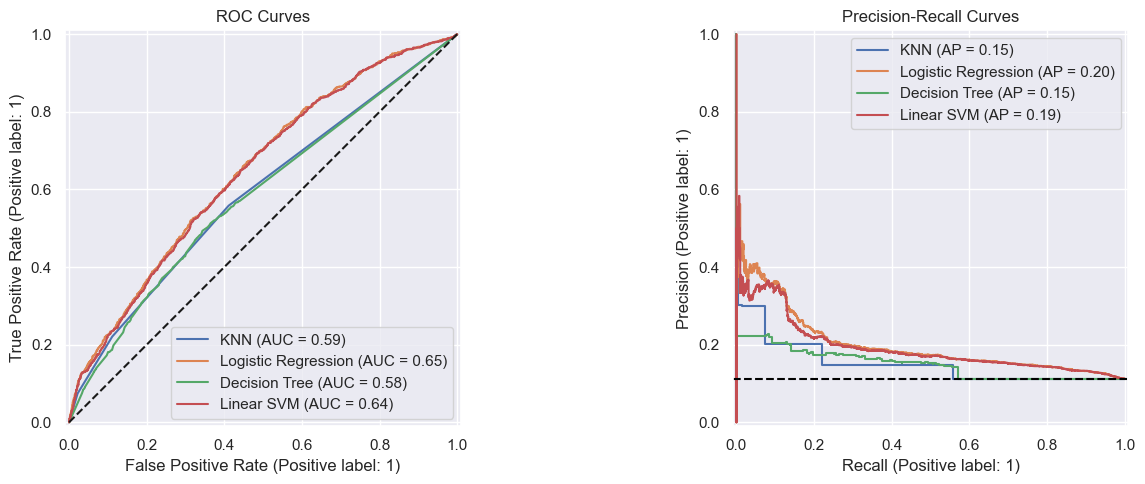

In [63]:
#ROC and Precision-Recall curves to evaluate the performance of  classification models. 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in fitted_default_models.items():

    RocCurveDisplay.from_estimator(
        model, X_test, y_test,
        name=name,
        ax=axes[0]
    )

    PrecisionRecallDisplay.from_estimator(
        model, X_test, y_test,
        name=name,
        ax=axes[1]
    )

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("ROC Curves")

axes[1].axhline(
    y_test.mean(),
    color="black",
    linestyle="--"
)
axes[1].set_title("Precision-Recall Curves")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


Interpretation:

Logistic regression gave the best results, with a ROC-AUC of 0.65 and average precision of 0.20. Linear SVM performed almost as well. KNN and the decision tree showed weaker results. Overall, the models performed better than random guessing, but the bank client features alone did not provide strong predictions.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [64]:
#defining hyperparametrers for each model to be used in grid search. 
parameter_grids = {
    "KNN": {
        "model__n_neighbors": [15, 35],
        "model__weights": ["uniform", "distance"]
    },

    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },

    "Decision Tree": {
        "model__max_depth": [4, 8, 12],
        "model__min_samples_leaf": [10, 25],
        "model__class_weight": [None, "balanced"]
    },

    "Linear SVM": {
        "model__C": [0.01, 0.1, 1],
        "model__class_weight": [None, "balanced"]
    }
}

In [65]:
#function to get model scores
def get_model_scores(model, X_data, batch_size=200):

    if not hasattr(model, "predict_proba"):
        return model.decision_function(X_data)

    scores = []

    for start in range(0, len(X_data), batch_size):
        batch = X_data.iloc[start:start + batch_size]
        scores.append(model.predict_proba(batch)[:, 1])

    return np.concatenate(scores)

In [66]:
tuned_results = []
best_tuned_models = {}

for model_name, classifier in default_models.items():

    pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", clone(classifier))
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=parameter_grids[model_name],
        scoring="average_precision",
        cv=cv,
        n_jobs=1,
        refit=True
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    predictions = best_model.predict(X_test)
    scores = get_model_scores(best_model, X_test)

    tuned_results.append({
        "Model": model_name,
        "CV Average Precision": grid_search.best_score_,
        "Test Average Precision": average_precision_score(
            y_test, scores
        ),
        "Test ROC-AUC": roc_auc_score(y_test, scores),
        "Test Accuracy": accuracy_score(
            y_test, predictions
        ),
        "Test Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Test Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "Test F1": f1_score(
            y_test, predictions, zero_division=0
        ),
        "Best Parameters": grid_search.best_params_
    })

    best_tuned_models[model_name] = best_model
 


In [67]:
tuned_results_df = (
    pd.DataFrame(tuned_results)
    .sort_values(
        "CV Average Precision",
        ascending=False
    )
    .reset_index(drop=True)
)

show_table(tuned_results_df.round(3))

,Model,CV Average Precision,Test Average Precision,Test ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Best Parameters
0,Decision Tree,0.2150,0.2100,0.6520,0.8850,0.3970,0.0330,0.0620,"{'model__class_weight': None, 'model__max_dept..."
1,KNN,0.2030,0.2000,0.6380,0.8870,0.5000,0.0320,0.0610,"{'model__n_neighbors': 35, 'model__weights': '..."
2,Logistic Regression,0.2020,0.2010,0.6490,0.8870,0.0000,0.0000,0.0000,"{'model__C': 0.1, 'model__class_weight': None}"
3,Linear SVM,0.1990,0.2000,0.6520,0.5870,0.1610,0.6340,0.2570,"{'model__C': 0.01, 'model__class_weight': 'bal..."


The Decision Tree had the highest cross-validation average precision of 0.215 and a test average precision of 0.210. The Decision Tree and Linear SVM both had a test ROC-AUC of about 0.652.

At the default threshold, Linear SVM had the highest recall of 63.4% and the highest F1-score of 25.7%. However, its precision was only 16.1%, which means it produced many false positives. Logistic Regression and KNN had high accuracy but identified very few subscribers. These results show why accuracy alone is not a good metric for this dataset and why threshold tuning is useful.

In [68]:

threshold_results = []

for name, model in  best_tuned_models.items():

    method = (
        "predict_proba"
        if hasattr(model, "predict_proba")
        else "decision_function"
    )

    # Cross-validated training scores
    cv_scores = cross_val_predict(
        model, X_train, y_train,
        cv=cv, method=method, n_jobs=1
    )

    if method == "predict_proba":
        cv_scores = cv_scores[:, 1]

    # Find threshold with highest F1
    precision, recall, thresholds = precision_recall_curve(
        y_train, cv_scores
    )

    f1_values = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-9)
    )

    best_threshold = thresholds[np.argmax(f1_values)]

    # Evaluate on test data
    test_scores = (
        model.predict_proba(X_test)[:, 1]
        if method == "predict_proba"
        else model.decision_function(X_test)
    )

    predictions = (test_scores >= best_threshold).astype(int)

    threshold_results.append({
        "Model": name,
        "Threshold": best_threshold,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions)
    })

threshold_comparison = pd.DataFrame(threshold_results)
show_table(threshold_comparison.round(3))

,Model,Threshold,Accuracy,Precision,Recall,F1
0,KNN,0.1710,0.7630,0.1990,0.3650,0.2580
1,Logistic Regression,0.1400,0.7580,0.1880,0.3470,0.2440
2,Decision Tree,0.1320,0.7550,0.1900,0.3600,0.2490
3,Linear SVM,0.0610,0.6780,0.1750,0.5000,0.2590


Interpretation:

Threshold tuning helped all four models identify more subscribers. Linear SVM had the highest recall of 50.0% and the highest F1-score of 25.9%. KNN had the highest accuracy of 76.3% and an F1-score of 25.8%. Logistic Regression achieved 34.7% recall and an F1-score of 24.4%.

The accuracy decreased because the models predicted more customers as subscribers instead of mainly predicting “No.” Also, the Linear SVM threshold is a decision score, not a probability, so it cannot be directly compared with the other thresholds.


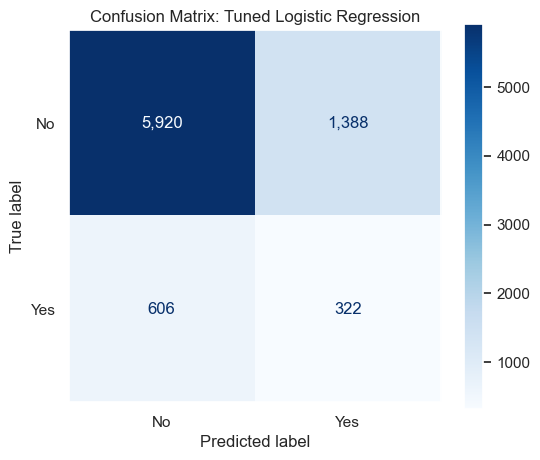

              precision    recall  f1-score   support

          No       0.91      0.81      0.86      7308
         Yes       0.19      0.35      0.24       928

    accuracy                           0.76      8236
   macro avg       0.55      0.58      0.55      8236
weighted avg       0.83      0.76      0.79      8236



In [69]:


model_name = "Logistic Regression"
model = best_tuned_models[model_name]

# Get the tuned threshold
threshold = threshold_comparison.loc[
    threshold_comparison["Model"] == model_name,
    "Threshold"
].iloc[0]

# Make predictions using the tuned threshold
test_scores = model.predict_proba(X_test)[:, 1]
test_predictions = (test_scores >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, test_predictions)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

fig, ax = plt.subplots(figsize=(6, 5))
cm_display.plot(cmap="Blues", values_format=",", ax=ax)
ax.set_title("Confusion Matrix: Tuned Logistic Regression")
plt.grid(False)
plt.show()

# Classification metrics
print(classification_report(
    y_test,
    test_predictions,
    target_names=["No", "Yes"],
    zero_division=0
))

Confusion Matrix Interpretation

The model correctly predicted 5,920 non-subscribers and 322 subscribers. It incorrectly predicted 1,388 non-subscribers as subscribers and missed 606 actual subscribers. The model identified about 35% of the subscribers, with a precision of about 19%. This means it found some potential subscribers, but it still missed many and produced a large number of false positives.

,Feature,Coefficient,Odds Ratio
22,categorical__default_unknown,-0.8870,0.4120
1,categorical__job_blue-collar,-0.3860,0.6790
2,categorical__job_entrepreneur,-0.3170,0.7280
7,categorical__job_services,-0.3070,0.7360
16,categorical__education_basic.9y,-0.2060,0.8140
6,categorical__job_self-employed,-0.1750,0.8400
9,categorical__job_technician,-0.1730,0.8410
4,categorical__job_management,-0.1640,0.8490
12,categorical__marital_married,0.1410,1.1510
14,categorical__marital_unknown,0.1490,1.1610


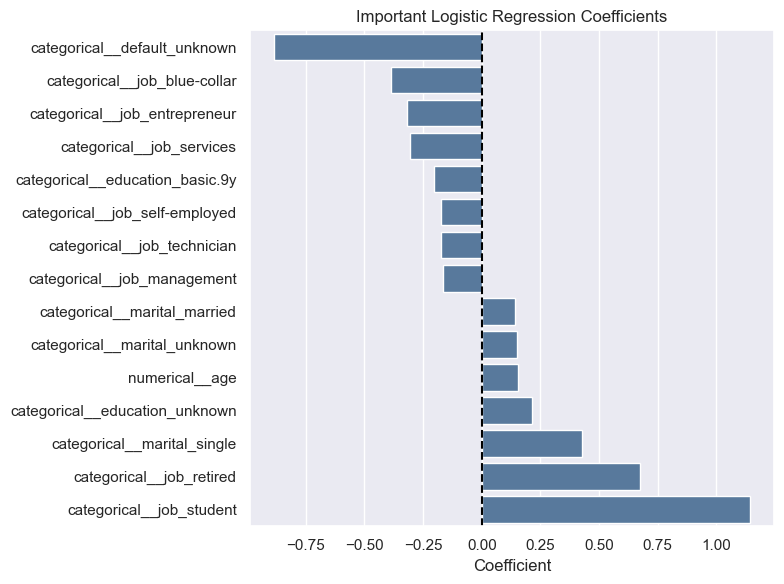

In [70]:
log_model = best_tuned_models["Logistic Regression"]

# Get feature names and coefficients
feature_names = (
    log_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = log_model.named_steps["model"].coef_[0]

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds Ratio": np.exp(coefficients)
})

coefficient_table["Importance"] = coefficient_table["Coefficient"].abs()

# Select the 15 most important coefficients
important_coefficients = (
    coefficient_table
    .nlargest(15, "Importance")
    .sort_values("Coefficient")
)

show_table(
    important_coefficients[
        ["Feature", "Coefficient", "Odds Ratio"]
    ].round(3)
)

# Plot coefficients
plt.figure(figsize=(8, 6))

sns.barplot(
    data=important_coefficients,
    x="Coefficient",
    y="Feature",
    color="#4C78A8"
)

plt.axvline(0, color="black", linestyle="--")
plt.title("Important Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("")
plt.tight_layout()
plt.show()

Interpretation:

The model shows that students and retired customers are more likely to subscribe. Single customers also have a higher chance of subscribing. Customers with an unknown default status are less likely to subscribe. Blue-collar workers, entrepreneurs, and service workers also show lower subscription rates. These results can help the bank identify customer groups for future campaigns, but they do not prove that these features directly cause subscription.

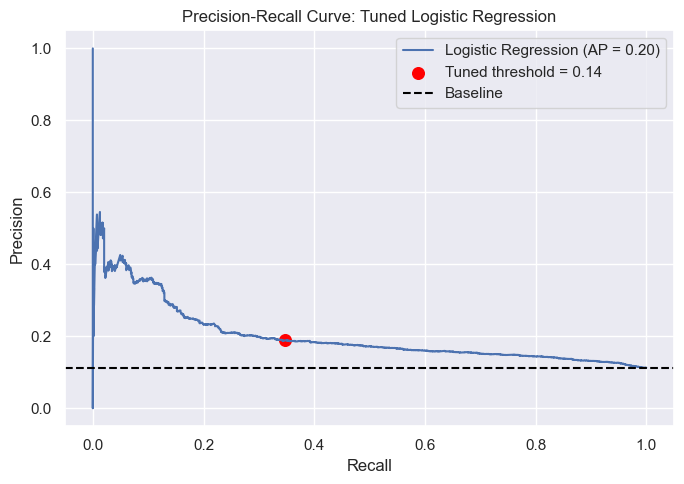

In [71]:
# Precision-Recall Curve for the tuned Logistic Regression model

model_name = "Logistic Regression"
model = best_tuned_models[model_name]

# Predicted probabilities
test_scores = model.predict_proba(X_test)[:, 1]

# Precision-recall values
precision, recall, thresholds = precision_recall_curve(
    y_test, test_scores
)

average_precision = average_precision_score(y_test, test_scores)

# Tuned threshold
best_threshold = threshold_comparison.loc[
    threshold_comparison["Model"] == model_name,
    "Threshold"
].iloc[0]

threshold_index = np.argmin(
    np.abs(thresholds - best_threshold)
)

# Plot
plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (AP = {average_precision:.2f})"
)

plt.scatter(
    recall[threshold_index],
    precision[threshold_index],
    color="red",
    s=70,
    label=f"Tuned threshold = {best_threshold:.2f}"
)

plt.axhline(
    y=y_test.mean(),
    color="black",
    linestyle="--",
    label="Baseline"
)

plt.title("Precision-Recall Curve: Tuned Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

Interpretation:

The Logistic Regression model had an average precision of 0.20, which was better than the baseline subscription rate of about 0.11. At the selected threshold of 0.14, the model had 34.7% recall and 18.8% precision. This means the model identified about one-third of the subscribers, but many customers predicted as subscribers did not actually subscribe. Increasing the threshold may improve precision, but it would also miss more subscribers.

## Findings:

- Only 11.3% of customers subscribed, so the target was highly imbalanced.
- The baseline accuracy was 88.7%, but the baseline model did not identify any subscribers.
- The Decision Tree had the highest cross-validation average precision of 0.215 and a test average precision of 0.210.
- The Decision Tree and Linear SVM both had a test ROC-AUC of about 0.652.
- After threshold tuning, Linear SVM had the highest recall of 50.0% and the highest F1-score of 25.9%.
- I used Logistic Regression for detailed interpretation because it was easier to explain.
- At a threshold of 0.14, Logistic Regression had 18.8% precision, 34.7% recall, and an F1-score of 24.4%.
- Logistic Regression correctly identified 322 subscribers but incorrectly identified 1,388 non-subscribers as subscribers.
- Students, retired customers, and single customers showed a higher likelihood of subscribing.
- These results show patterns in the data but do not prove that these features caused customers to subscribe.


## Recommendations:

- The bank should contact customers with the highest predicted subscription probabilities first.<br>
- The decision threshold should be adjusted based on how many customers the bank can contact.<br>
- A higher threshold can reduce unnecessary calls, but it may also miss some subscribers.<br>
- More customer and previous campaign information may help improve the model.<br>
- Call duration should not be used for advance predictions because it is only known after the call.<br>
- The bank should first test the model on a small campaign and check the results before using it on a larger scale.<br>

# Limitations:

- The data is imbalanced because only 11.3% of customers subscribed.<br>
- I only used customer banking features, so the models had limited information.<br>
- The Logistic Regression model had low precision and produced many false positives.<br>
- I did not use call duration because it is only known after the call.<br>
- Some columns contained "unknown" values.<br>
- The data came from one bank in Portugal, so the results may be different for other banks.<br>
- The results show patterns in the data, but they do not prove that these features cause customers to subscribe.<br>

# Next Steps
- Test the Logistic Regression model on a small marketing campaign.<br>
- Select a final threshold based on the bank’s budget and calling capacity.<br>
- Collect more customer information that is available before the call.<br>
- Compare the results with other models, such as Random Forest or Gradient Boosting.<br>
- Check whether the model performs fairly across different customer groups.<br>
- Monitor precision and recall over time and retrain the model when performance decreases.<br>

# Conclusion

In this project, I compared four models to predict whether a customer would subscribe to a term deposit. Since the data was imbalanced, I focused on precision, recall, F1-score, and average precision instead of accuracy alone. Linear SVM had the highest recall and F1-score after threshold tuning, while the Decision Tree had the highest average precision. I used Logistic Regression for detailed interpretation because it was easier to explain. At the selected threshold, it identified about 35% of subscribers with a precision of about 19%. The model can help the bank rank customers for future calls, but it should be tested before being used in a real campaign.